In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, Dataset,random_split
from torchvision.datasets import DatasetFolder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import random
from collections import Counter
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt
import os
import pandas as pd

epochs=20
batch_size=32
lr=4e-3

conv1_channels=32
conv2_channels=64
dropout=0.3
fc_hidden=128
arch="skip_concat"

c:\Users\lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class baselineCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super(baselineCNN, self).__init__()

        self.conv1 = nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.fc_hidden = fc_hidden
        self.num_classes = num_classes

        self.fc1 = None
        self.fc2 = None

    def _init_fc(self, x):
        flatten_dim = x.view(x.size(0), -1).shape[1]
        self.fc1 = nn.Linear(flatten_dim, self.fc_hidden).to(x.device)
        self.fc2 = nn.Linear(self.fc_hidden, self.num_classes).to(x.device)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        if self.fc1 is None:
            self._init_fc(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class residualCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.block1 = ResidualBlock(conv1_channels, conv1_channels, stride=1)
        self.block2 = ResidualBlock(conv1_channels, conv2_channels, stride=2)
        self.block3 = ResidualBlock(conv2_channels, conv2_channels, stride=1)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(conv2_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class resnetTinyCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        c3 = max(conv2_channels, conv1_channels * 2)
        self.stem = nn.Sequential(
            nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(conv1_channels, conv1_channels, stride=1),
            ResidualBlock(conv1_channels, conv1_channels, stride=1),
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(conv1_channels, conv2_channels, stride=2),
            ResidualBlock(conv2_channels, conv2_channels, stride=1),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(conv2_channels, c3, stride=2),
            ResidualBlock(c3, c3, stride=1),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(c3, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


class skipConcatCNN(nn.Module):
    def __init__(
        self,
        num_channels,
        num_classes,
        conv1_channels=32,
        conv2_channels=64,
        dropout=0.3,
        fc_hidden=128,
    ):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(num_channels, conv1_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(conv1_channels),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(conv2_channels),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)
        self.fuse = nn.Sequential(
            nn.Conv2d(conv1_channels + conv2_channels, conv2_channels, kernel_size=1),
            nn.BatchNorm2d(conv2_channels),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(conv2_channels, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, num_classes)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.pool1(x1)
        x2 = self.enc2(x2)
        x2 = self.pool2(x2)

        x1_ds = F.adaptive_avg_pool2d(x1, output_size=x2.shape[-2:])
        x = torch.cat([x1_ds, x2], dim=1)
        x = self.fuse(x)
        x = self.pool(x).view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        return self.fc2(x)


def _build_cnn_model(
    arch,
    num_channels,
    num_classes,
    conv1_channels,
    conv2_channels,
    dropout,
    fc_hidden,
):
    if arch == "residual":
        return residualCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    if arch == "resnet":
        return resnetTinyCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    if arch == "skip_concat":
        return skipConcatCNN(
            num_channels=num_channels,
            num_classes=num_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            dropout=dropout,
            fc_hidden=fc_hidden,
        )
    return baselineCNN(
        num_channels=num_channels,
        num_classes=num_classes,
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        fc_hidden=fc_hidden,
    )

In [3]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [5]:
class CodasDataset(Dataset):
    def __init__(self, paths,labels, transform=None):
        self.img_paths = paths
        self.img_labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        data = np.load(self.img_paths.iloc[idx])
        image = torch.from_numpy(data['recurrence_plots'])
        label = self.img_labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [6]:
records_df = pd.read_csv(r"E:/CoDaS Project/Radar/C3_RP_windows/windowed_rp_manifest.csv")
paths=records_df['file']
labels=records_df['emotion']
users=records_df['user_id']
num_channels = 39

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)

In [7]:
#Split dataset based on users to ensure no data leakage between train and test sets
unique_users=list(set(users))
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

test_indices = np.argwhere(np.isin(users, test_users)).ravel()
train_indices = np.argwhere(np.isin(users, train_users)).ravel()

train_paths = paths[train_indices]
train_y = labels_encoded[train_indices]
test_paths = paths[test_indices]
test_y = labels_encoded[test_indices]

print(f"Train set: {len(train_paths)} samples, Test set: {len(test_paths)} samples")

class_weights = compute_class_weight('balanced', classes=np.unique(train_y), y=train_y)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

train_ds = CodasDataset(train_paths, torch.tensor(train_y, dtype=torch.int64))
test_ds = CodasDataset(test_paths, torch.tensor(test_y, dtype=torch.int64))
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Train set: 3047 samples, Test set: 890 samples


In [8]:
model = _build_cnn_model(
        arch=arch,
        num_channels=num_channels,
        num_classes=num_classes,
        conv1_channels=conv1_channels,
        conv2_channels=conv2_channels,
        dropout=dropout,
        fc_hidden=fc_hidden,
    ).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {arch}, Parameters: {count_parameters(model)}")

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

Model: skip_concat, Parameters: 45382



=== TRAINING START ===


epoch 1/20:   0%|          | 0/96 [00:00<?, ?it/s]

epoch 1/20, train_loss=1.7143, val_loss=1.7356


epoch 2/20, train_loss=1.6653, val_loss=1.7349


epoch 3/20, train_loss=1.6394, val_loss=1.6722


...

epoch 16/20, train_loss=1.4509, val_loss=1.7644


epoch 17/20, train_loss=1.4472, val_loss=2.2591


epoch 18/20, train_loss=1.4174, val_loss=1.6232


epoch 19/20, train_loss=1.3967, val_loss=1.9393


epoch 20/20, train_loss=1.3734, val_loss=1.6103

=== WINDOW-LEVEL PERFORMANCE ===
              precision    recall  f1-score   support

         E01       0.24      0.20      0.22       131
         E02       0.50      0.60      0.55       302
         E03       0.26      0.12      0.16       181
         E04       0.34      0.56      0.42       106
         E05       0.21      0.05      0.08        64
         E06       0.26      0.36      0.30       106

    accuracy                           0.37       890
   macro avg       0.30      0.31      0.29       890
weighted avg       0.34      0.37      0.34       890

window-level accuracy: 0.3685
window-level balanced accuracy: 0.3126


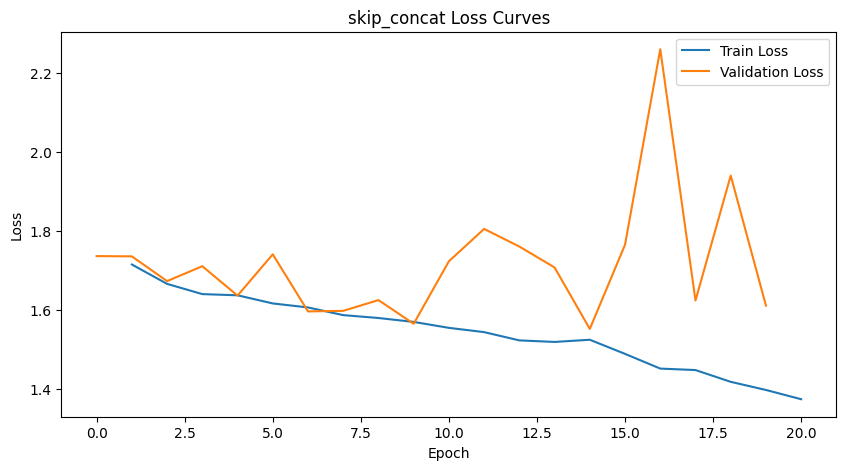

In [9]:
train_loss_history = []
val_loss_history = []
print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss_history.append(total_loss / len(train_loader))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    val_loss_history.append(val_loss / len(test_loader))
    print(f"epoch {epoch+1}/{epochs}, train_loss={total_loss / len(train_loader):.4f}, val_loss={val_loss / len(test_loader):.4f}")
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{arch} Loss Curves")
plt.legend()
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

acc_window = accuracy_score(all_true, all_preds)
bal_acc_window = balanced_accuracy_score(all_true, all_preds)
print("\n=== WINDOW-LEVEL PERFORMANCE ===")
report_labels = list(range(num_classes))
print(
    classification_report(
        all_true,
        all_preds,
        labels=report_labels,
        target_names=le.classes_,
        zero_division=0,
    )
)
print(f"window-level accuracy: {acc_window:.4f}")
print(f"window-level balanced accuracy: {bal_acc_window:.4f}")

Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

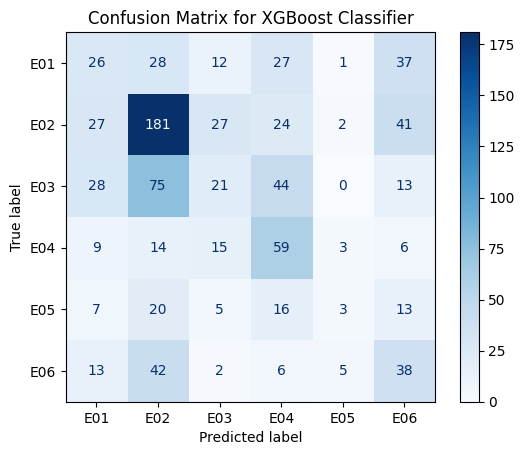

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")